In [25]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_case_data_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(4950, 8)


In [21]:
# remove model_name == 'Random'


(4500, 8)
['Model10' 'Model100' 'Model20' 'Model30' 'Model40' 'Model50' 'Model60'
 'Model70' 'Model80' 'Model90']
          case_name model_name  case_seed metric_name  mean_val   std_val  \
0  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
1  100k-100seg-100H    Model10         53     AUC-ROC  0.100225  0.002738   
2  100k-100seg-100H    Model10         53      Aff-F1  0.599683  0.008507   
3  100k-100seg-100H    Model10         53          F1  0.007339  0.000856   
4  100k-100seg-100H    Model10         53       F1-PA  0.511857  0.041889   

   mean_latency  std_latency  
0     21.221560     0.059661  
1     28.568022     0.162600  
2    808.004104     2.556749  
3     38.742157     0.227650  
4     99.825350     0.573268  


In [24]:
import re
def case_name_split(case_name_list):
    pattern = r'(\w+)k-(\w+)seg-(\w+)'
    case_name_split_list = []
    for case_name in case_name_list:
        match = re.match(pattern, case_name)
        if match:
            case_split = match.groups()
            case_split = [int(case_split[0])*1000, int(case_split[1]), case_split[2]]
            case_name_split_list.append(case_split)
        else:
            print(f"Pattern not matched for {case_name}")
    return case_name_split_list

case_name_list = data['case_name']
case_name_split_list = case_name_split(case_name_list)
case_data = pd.DataFrame(case_name_split_list, columns=['ts_len', 'seg', 'seg_type'])
# merge the new columns with the original data
print(data.shape, case_data.shape)
# data_new = pd.merge(data, case_data, on='case_name', how='left')
data_new = pd.concat([data, case_data], axis=1)
data_new = data_new[data_new['model_name'] != 'Random']
print(data_new.shape)

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    '20L', '20H', '50L', '50H', '100L', '100H', '500L', '500H',
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx


print(data_new.head())
print(data_new.columns)

(4500, 8) (4500, 4)
(675000, 11)
          case_name model_name  case_seed metric_name  mean_val   std_val  \
0  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
1  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
2  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
3  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
4  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   

   mean_latency  std_latency  ts_len  seg seg_type  
0      21.22156     0.059661  100000  100     100H  
1      21.22156     0.059661  100000  100     100H  
2      21.22156     0.059661  100000  100     100H  
3      21.22156     0.059661  100000  100     100H  
4      21.22156     0.059661  100000  100     100H  
Index(['case_name', 'model_name', 'case_seed', 'metric_name', 'mean_val',
       'std_val', 'mean_latency', 'std_latency', 'ts_len', 'seg', 'seg_type'],
      dtype='object')


In [15]:
# todo
# import matplotlib.pyplot as plt
# import seaborn as sns
# # 1. 相同长度下，不同指标的latency分布图
# def plot_latency_distribution(data, ts_len):
    

#     filtered_data = data[data['ts_len'] == ts_len]
#     metric_names = filtered_data['metric_name'].unique()
#     for metric in metric_names:
#         metric_data = filtered_data[filtered_data['metric_name'] == metric]
#         metric_data = metric_data.sort_values(by=['seg_type'], key=lambda x: x.apply(sort_seg_type_key))
#         # metric_latency = metric_data['mean_latency']
#         plt.figure(figsize=(4, 6))
#         sns.boxplot(x='seg_type', y='mean_latency', data=metric_data)
#         plt.title(f'Latency Distribution for ts_len = {ts_len}, Metric = {metric}')
#         plt.xlabel('Segment Type')
#         plt.ylabel('Latency')
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

# plot_latency_distribution(data_new, 10000)  # Example for ts_len = 1000


/tmp/ipykernel_3929163/179052625.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric   Avg. Latency   Std. Latency  Avg. Latency per point
0           F1      45.573132      20.482165                0.000456
1        F1-PA     107.999642      22.849366                0.001080
2   Reduced-F1     118.713293      18.310710                0.001187
3         PA%K    9875.633882    1839.725867                0.098756
4   R-based F1     458.455779     210.908978                0.004585
5         TaPR    5518.453089    7681.094374                0.055185
6        eTaPR    3761.316995    5092.336282                0.037613
7       Aff-F1    1043.136484    1371.576453                0.010431
8      NAff-F1    1016.671182    1245.096886                0.010167
9      UAff-F1    1004.392434    1209.517910                0.010044
10        PATE  221593.946124  233762.334468                2.215939
11     AUC-ROC      39.036853      35.735310                0.000390
12      AUC-PR      25.890204      18.643608                0.000259
13     VUS-ROC   22429.903837   24

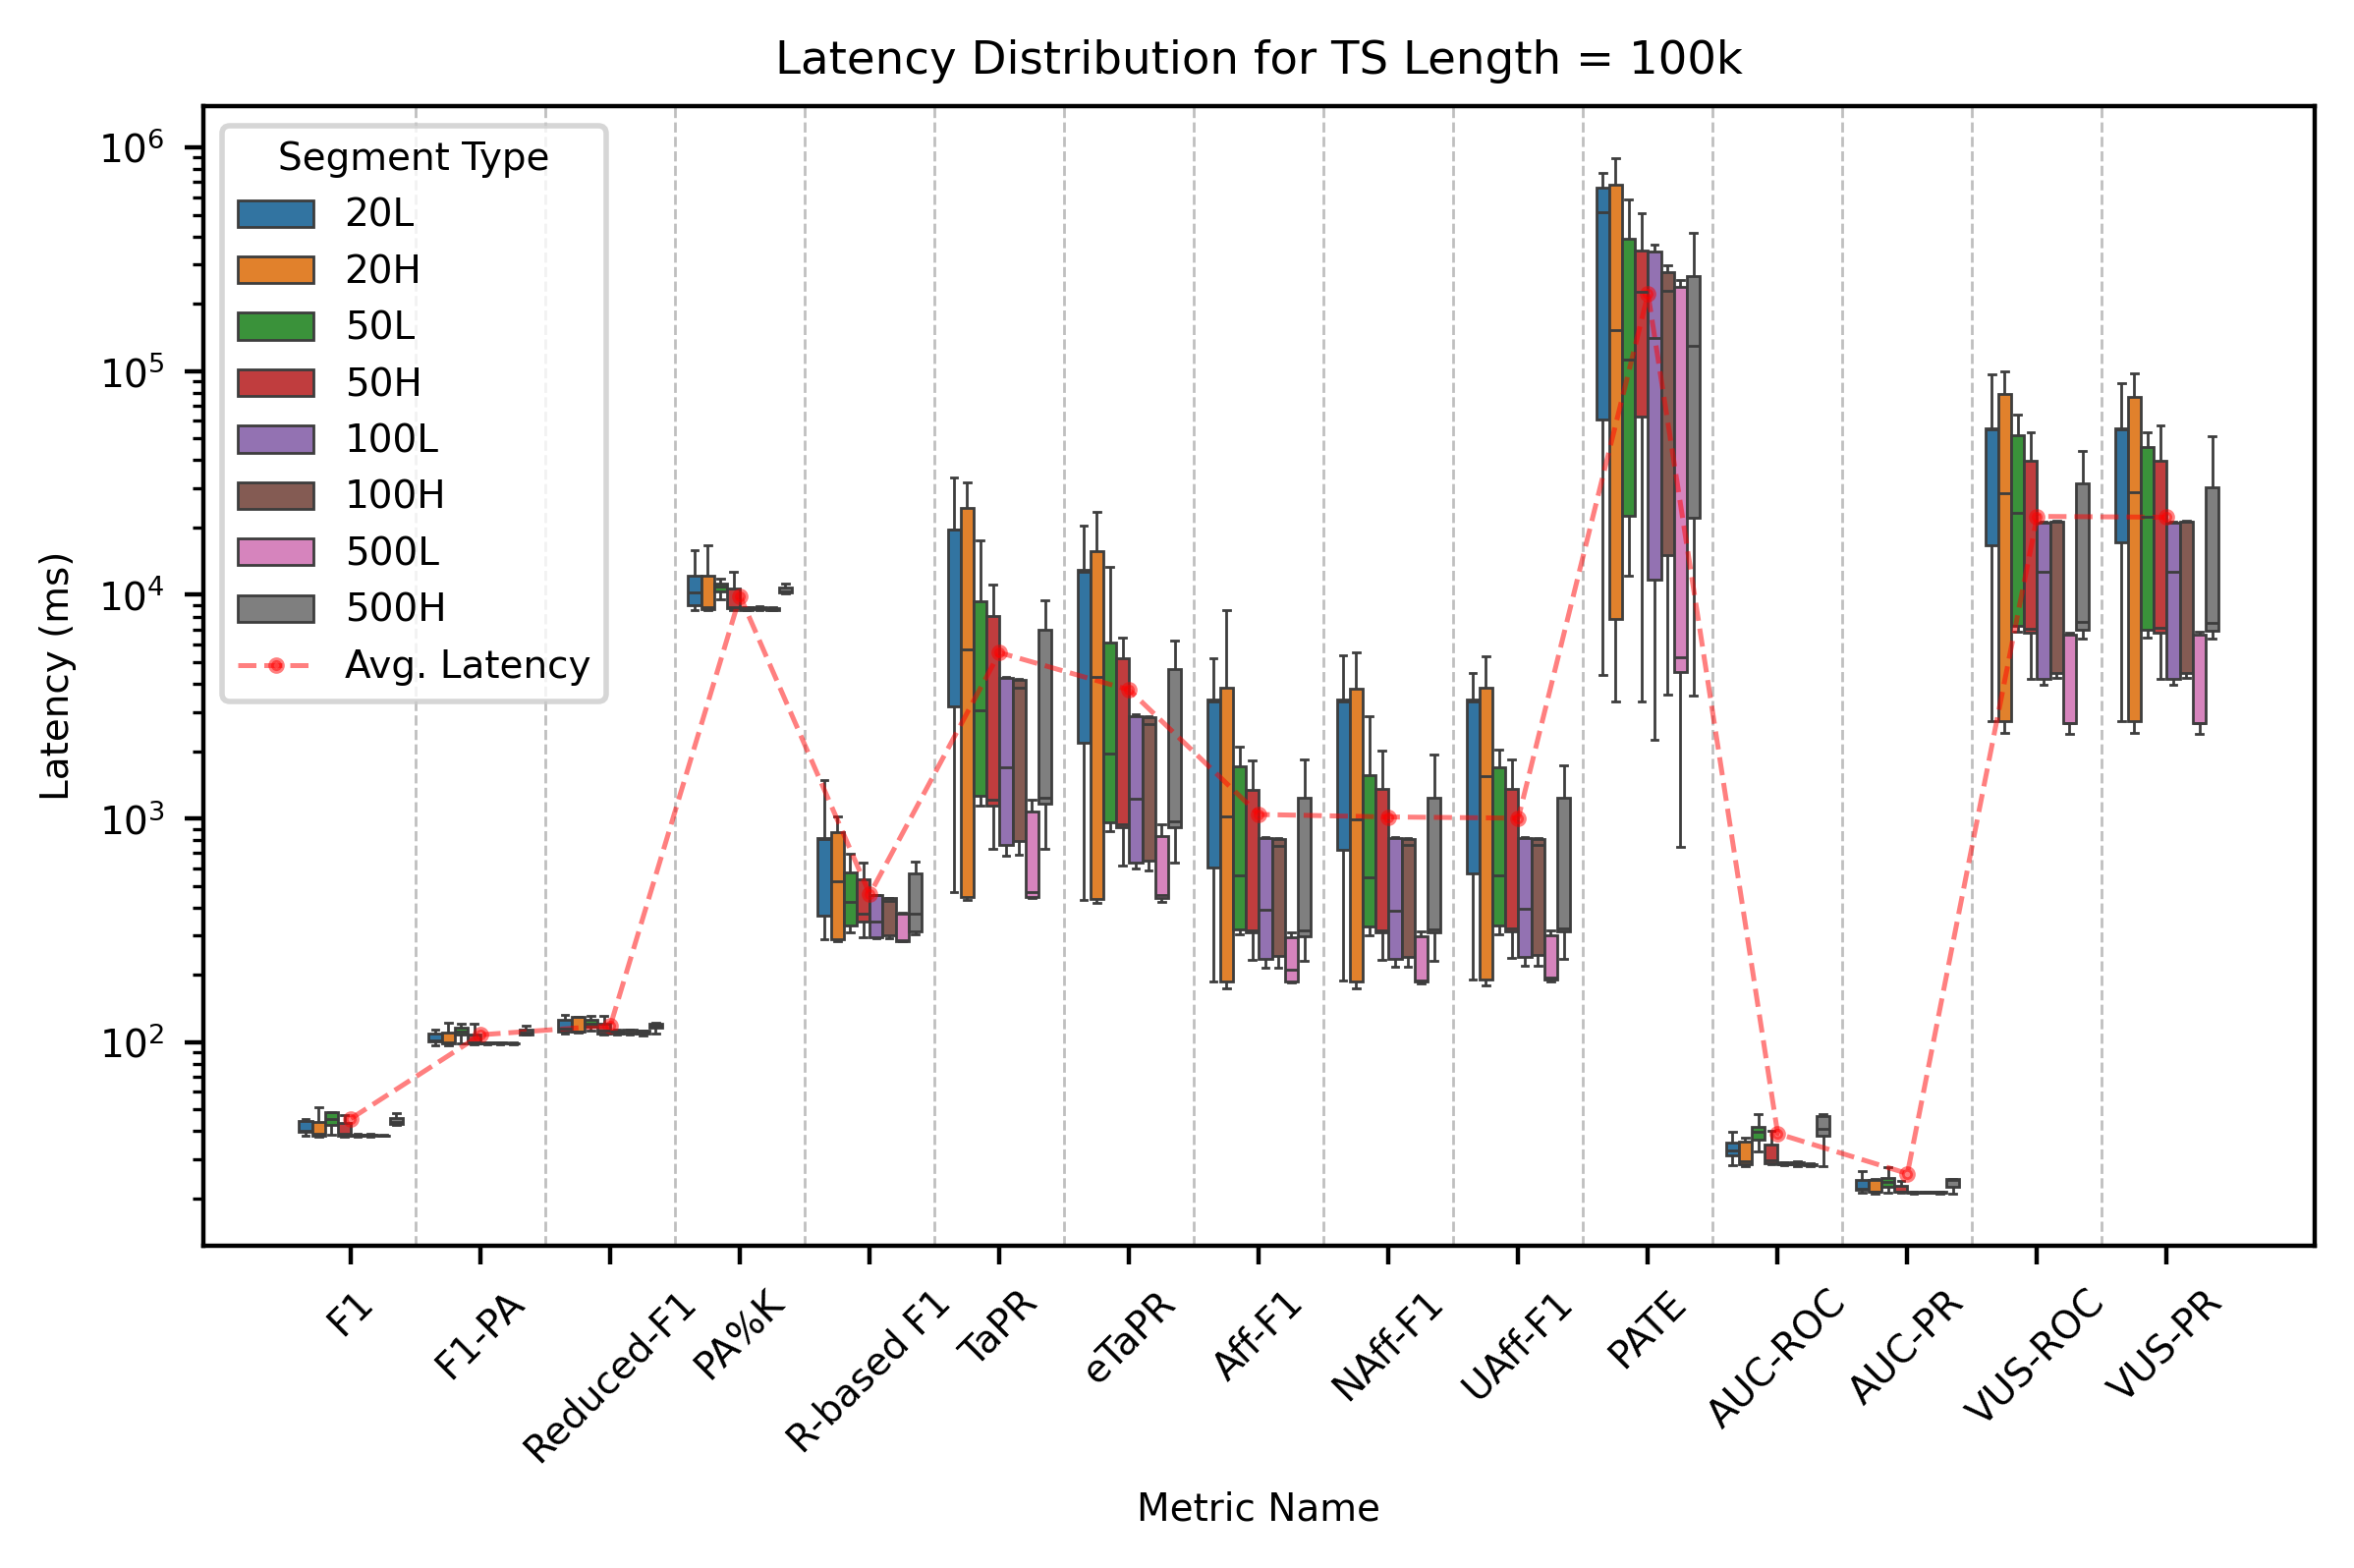

/tmp/ipykernel_3929163/179052625.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


        Metric  Avg. Latency  Std. Latency  Avg. Latency per point
0           F1     13.858503     35.802387                0.001386
1        F1-PA     31.651361     78.605927                0.003165
2   Reduced-F1     34.071211     77.041728                0.003407
3         PA%K   2406.575904   4401.115945                0.240658
4   R-based F1     72.891597    120.893665                0.007289
5         TaPR    436.280504   1045.702460                0.043628
6        eTaPR    343.193828    840.068414                0.034319
7       Aff-F1     99.868379    232.977650                0.009987
8      NAff-F1     94.013087    208.270587                0.009401
9      UAff-F1    108.529834    258.956474                0.010853
10        PATE   8368.964663  15609.587388                0.836896
11     AUC-ROC     11.055404     28.082276                0.001106
12      AUC-PR      5.444862     10.132103                0.000544
13     VUS-ROC   3892.959639   6061.396361                0.38

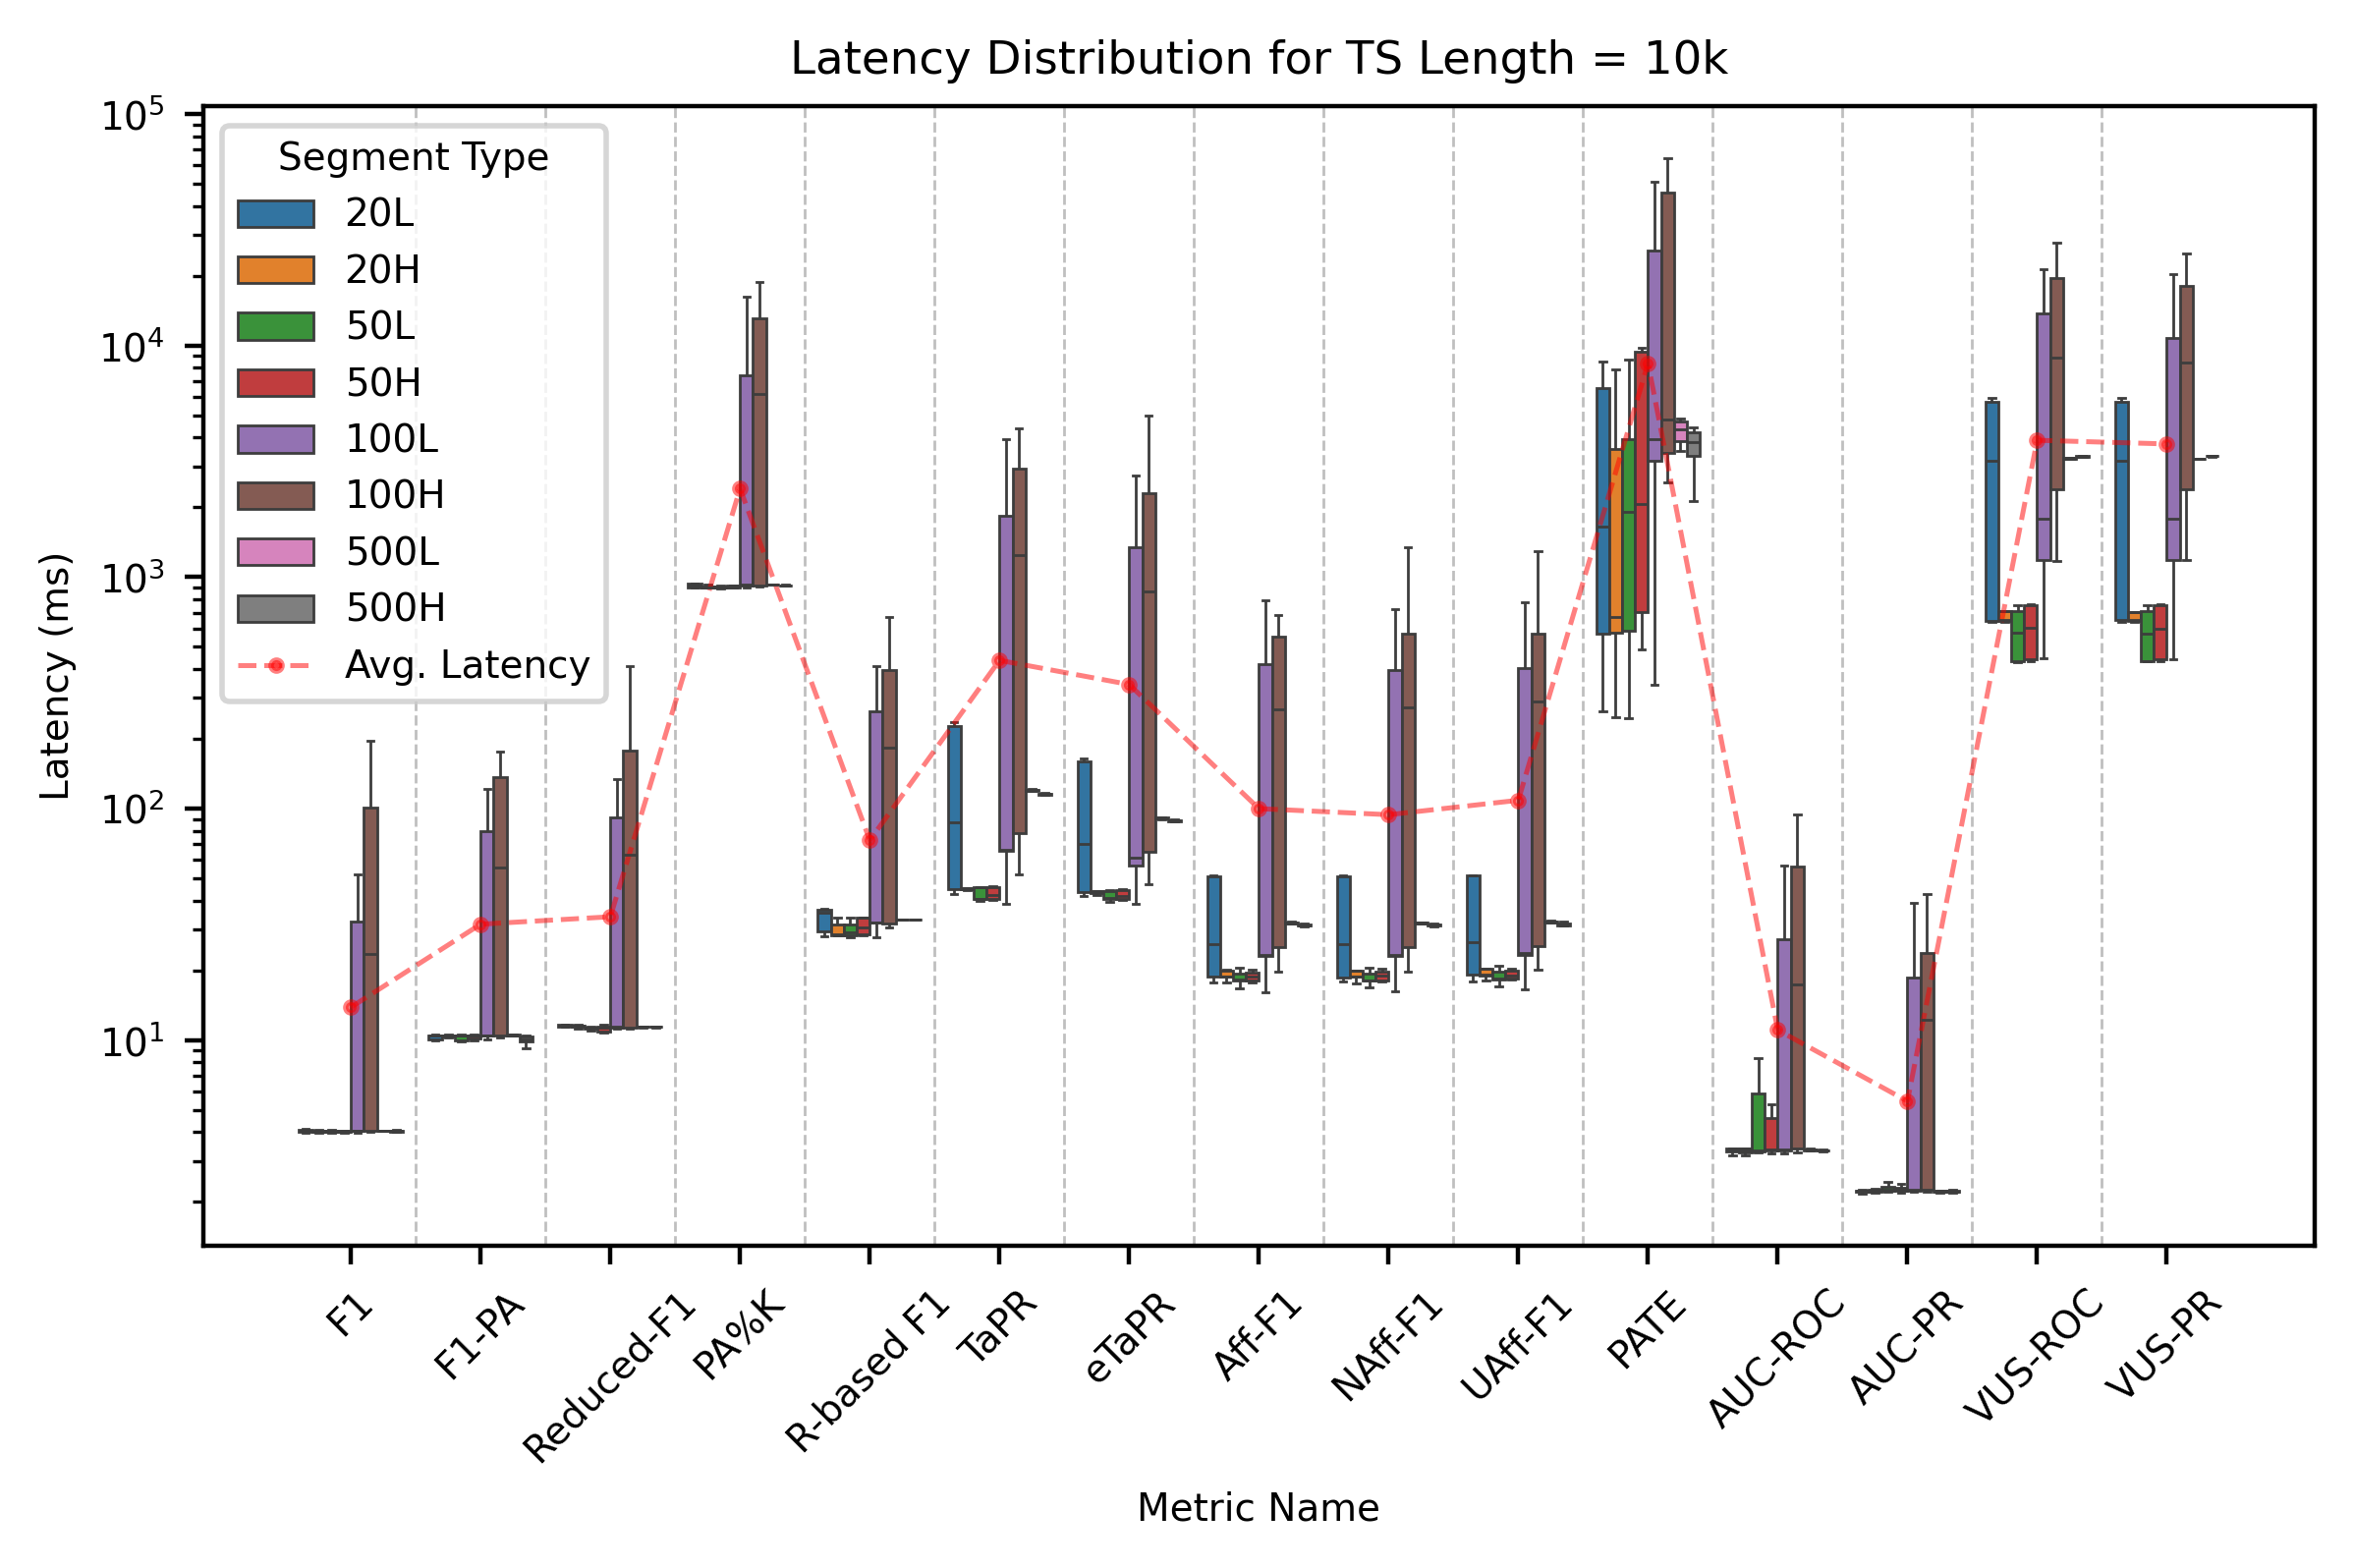

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_latency'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_latency'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    out_pth = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}.csv'
    # 转置
    saving_df = pd.merge(mean_values, std_values, on='metric_name', suffixes=('_mean', '_std'))
    saving_df.columns = ['Metric', 'Avg. Latency', 'Std. Latency']
    saving_df['Avg. Latency per point'] = saving_df['Avg. Latency'] / ts_len
    print(saving_df)
    saving_df.to_csv(out_pth, index=False)
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    mean_values = mean_values.to_numpy()
    plt.plot(mean_values[:, 0], mean_values[:, 1], color='red', marker='o', markersize=2, label='Avg. Latency'
             , linestyle='--', linewidth=0.9,
            #  透明度
                alpha=0.5
             )
    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    
        
    plt.legend(title='Segment Type')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

In [17]:
def plot_latency_distribution2(data_new):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    # delete nan
    # seg_list = [s for s in seg_list if pd.notna(s)]
    print(seg_list)
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort segments numerically
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
                # palette='Set2'  # END: Changed color palette
    # min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_latency'].agg(['min', 'max']).reset_index()
    # min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    # seg_list = df['seg'].unique()
    # seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 

    # min_max_ratios_max = min_max_ratios.groupby('metric_name')['ratio'].max().reset_index()
    # print(min_max_ratios_max)
    # for i, metric in enumerate(metric_sort):
    #     plt.annotate(
    #         f'Max Ratio: {min_max_ratios_max[min_max_ratios_max["metric_name"] == metric]["ratio"].values[0]:.2f}',
    #         xy=(i, 1.05),  # Adjust the y-coordinate for better visibility
    #         ha='center', va='bottom', fontsize=6, color='black'
    #     )
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Segment')
    plt.title(f'Latency Distribution Across Different Anomalous Segment Lengths')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/ts_len_latency.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments


[100.  10. 200.  20.   2. 500.  50.   1.   5.  nan]


ValueError: cannot convert float NaN to integer

<Figure size 2400x1600 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_latency_distribution3(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        try:
            if tmp.startswith('Model'):
                num_part = tmp.split('Model')[-1]
                return int(num_part)
            else:
                return -float('inf')
        except:
            print(f"Error sorting model name: {tmp}")
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_latency'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Model')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_latency_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000

Error sorting model name: nan


TypeError: '<' not supported between instances of 'NoneType' and 'int'

<Figure size 2400x1600 with 0 Axes>